In [1]:
# imports
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp
from gseapy import Biomart
bm = Biomart()
from gseapy import barplot

## Prepare data for analysis

In [2]:
# the DGE results were obtained with limma-voom. The following files contain the results of the DGE analysis for each comparison.

Tx_0_12 = pd.read_csv('/home/cvillazon/limma_voom_M_F/ZT0TxvsZT12Tx.csv', header=0)
Tx0_V12 = pd.read_csv('/home/cvillazon/limma_voom_M_F/ZT0TxvsZT12V.csv', header=0)
V_0_12 = pd.read_csv('/home/cvillazon/limma_voom_M_F/ZT0VvsZT12V.csv', header=0)

In [3]:
# Write new column with the regulation status of each gene based on the logFC and adj.P.Val values. 
# Add log10(padj) column for the volcano plot

Tx_0_12['-log10(padj)'] = -np.log10(Tx_0_12['adj.P.Val'])
Tx_0_12["regulation"] = np.where((Tx_0_12['adj.P.Val'] < 0.1) & (Tx_0_12['logFC'] > 0), 'Up',
                                              np.where((Tx_0_12['adj.P.Val'] < 0.1) & (Tx_0_12['logFC'] < 0), 'Down', 
                                                      'Unchange'))

Tx0_V12['-log10(padj)'] = -np.log10(Tx0_V12['adj.P.Val'])
Tx0_V12["regulation"] = np.where((Tx0_V12['adj.P.Val'] < 0.1) & (Tx0_V12['logFC'] > 0), 'Up',
                                              np.where((Tx0_V12['adj.P.Val'] < 0.1) & (Tx0_V12['logFC'] < 0), 'Down', 
                                                      'Unchange'))
V_0_12['-log10(padj)'] = -np.log10(V_0_12['adj.P.Val'])
V_0_12["regulation"] = np.where((V_0_12['adj.P.Val'] < 0.1) & (V_0_12['logFC'] > 0), 'Up',
                                              np.where((V_0_12['adj.P.Val'] < 0.1) & (V_0_12['logFC'] < 0), 'Down', 
                                                      'Unchange'))

Tx_0_12

,logFC,AveExpr,t,P.Value,adj.P.Val,-log10(padj),regulation
ENSMUSG00000032010,-4.335224,4.253806,-17.902388,7.839969e-15,9.677911e-11,10.014218,Down
ENSMUSG00000038550,-6.011835,1.898804,-17.497804,1.252642e-14,9.677911e-11,10.014218,Down
ENSMUSG00000022389,-2.881077,6.630992,-16.994536,2.269352e-14,1.168867e-10,9.932235,Down
ENSMUSG00000059824,-6.144251,3.072738,-16.665329,3.381270e-14,1.306185e-10,9.883995,Down
ENSMUSG00000015357,2.636709,6.985664,14.856616,3.410423e-13,1.053957e-09,8.977177,Up
...,...,...,...,...,...,...,...
ENSMUSG00000041879,0.015859,5.292777,0.000000,1.000000e+00,1.000000e+00,-0.000000,Unchange
ENSMUSG00000055670,0.013770,6.851400,0.000000,1.000000e+00,1.000000e+00,-0.000000,Unchange
ENSMUSG00000033306,0.000048,7.312856,0.000000,1.000000e+00,1.000000e+00,-0.000000,Unchange
ENSMUSG00000038664,0.000434,7.211826,0.000000,1.000000e+00,1.000000e+00,-0.000000,Unchange


## Volcano plots

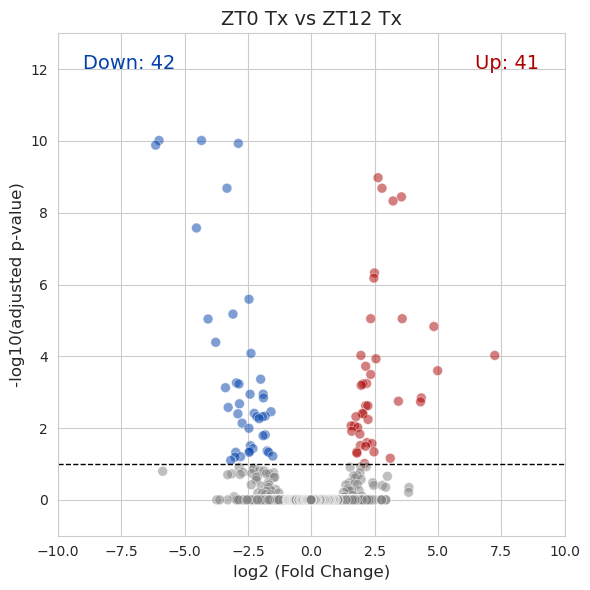

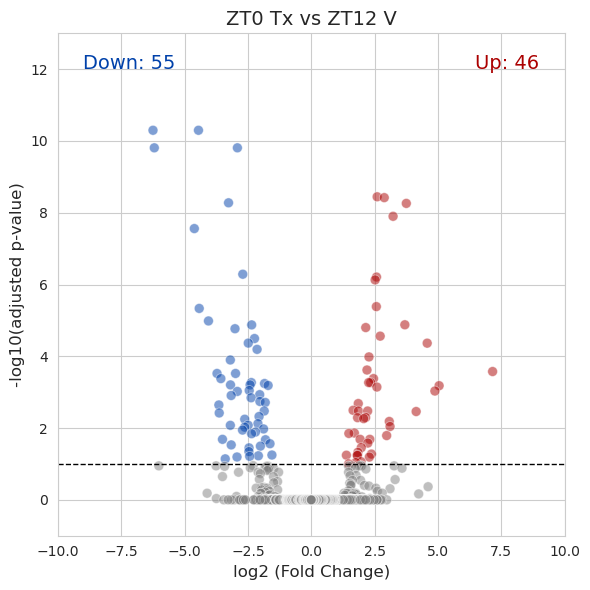

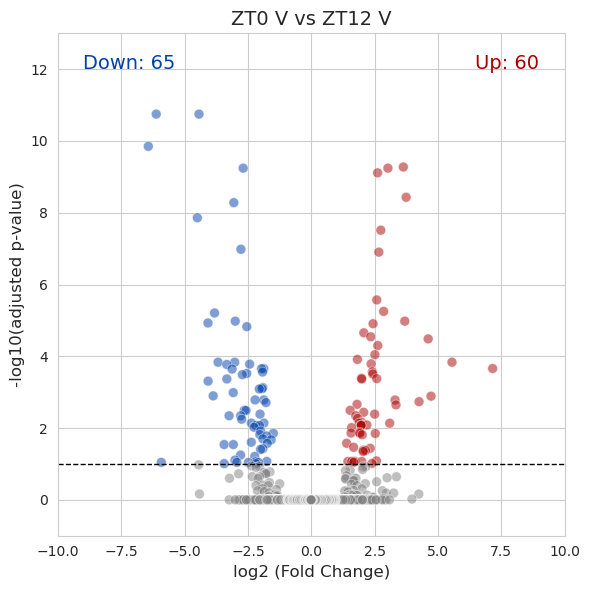

In [4]:
# Volcano plot function

palette = {
    "Up": "#ab0000",      # red
    "Down": "#0041aa",    # blue
    "Unchange": "gray"
}

def volcano_plot(df, title):

    plt.figure(figsize=(6,6))
    with sns.axes_style("whitegrid"):
        sns.scatterplot(
            data=df, 
            x="logFC", 
            y= "-log10(padj)", 
            hue="regulation",
            palette=palette,
            s=50,
            alpha=0.5,
            legend=None
        )

    # Cutoff lines
    plt.axhline(1, color="black", linestyle="--", linewidth=1)

    # Count categories
    up_count = (df["regulation"] == "Up").sum()
    down_count = (df["regulation"] == "Down").sum()

    plt.text(-9, 12, f"Down: {down_count}", fontsize=14, color='#0041aa', ha='left' )
    plt.text(9, 12, f"Up: {up_count}", fontsize=14, color='#ab0000', ha='right')

    # Labels
    plt.xlabel("log2 (Fold Change)", fontsize=12)
    plt.ylabel("-log10(adjusted p-value)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(-10,10)
    plt.ylim(-1,13)

    plt.tight_layout()
    plt.show()

volcano_plot(Tx_0_12, "ZT0 Tx vs ZT12 Tx")
volcano_plot(Tx0_V12, "ZT0 Tx vs ZT12 V")
volcano_plot(V_0_12, "ZT0 V vs ZT12 V")

## Ontologies

In [5]:
# Function to retrieve gene annotations from Ensembl using Biomart

def annotations(df):
    queries ={'ensembl_gene_id': list(list(df[df["regulation"] != "Unchange"].index)) } 
    results = bm.query(dataset='mmusculus_gene_ensembl',
                   attributes=['ensembl_gene_id', 'external_gene_name', 'entrezgene_id', 'go_id'],
                   filters=queries)
    df = pd.merge(df, results, left_index=True, right_on='ensembl_gene_id', how='left')
    return df
Tx_0_12 = annotations(Tx_0_12)
Tx0_V12 = annotations(Tx0_V12)
V_0_12 = annotations(V_0_12)

In [6]:
Tx_0_12.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,-log10(padj),regulation,ensembl_gene_id,external_gene_name,entrezgene_id,go_id
859.0,-4.335224,4.253806,-17.902388,7.839969e-15,9.677911e-11,10.014218,Down,ENSMUSG00000032010,Usp2,53376,GO:0004843
860.0,-4.335224,4.253806,-17.902388,7.839969e-15,9.677911e-11,10.014218,Down,ENSMUSG00000032010,Usp2,53376,GO:0016579
861.0,-4.335224,4.253806,-17.902388,7.839969e-15,9.677911e-11,10.014218,Down,ENSMUSG00000032010,Usp2,53376,GO:0005737
862.0,-4.335224,4.253806,-17.902388,7.839969e-15,9.677911e-11,10.014218,Down,ENSMUSG00000032010,Usp2,53376,GO:0005634
863.0,-4.335224,4.253806,-17.902388,7.839969e-15,9.677911e-11,10.014218,Down,ENSMUSG00000032010,Usp2,53376,GO:0016787


In [7]:
# to perform the enrichment analysis, get the gene names form library (gene sets)

names_library = gp.get_library_name(organism='Mouse')
names_library

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

{title}
                      Gene_set  \
0  GO_Biological_Process_2025   
1  GO_Biological_Process_2025   
2  GO_Biological_Process_2025   
3  GO_Biological_Process_2025   
4  GO_Biological_Process_2025   

                                                Term Overlap   P-value  \
0  Entrainment of Circadian Clock by Photoperiod ...    4/21  0.000002   
1                        Photoperiodism (GO:0009648)    4/22  0.000002   
2          Nucleoside Metabolic Process (GO:0009116)     2/9  0.000601   
3  Cellular Response to Peptide Hormone Stimulus ...    4/94  0.000633   
4               Lipid Catabolic Process (GO:0016042)    3/42  0.000704   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000499            0                     0   59.270290   
1          0.000499            0                     0   55.974684   
2          0.073774            0                     0   70.229277   
3          0.073774            0                     0   11.154430 

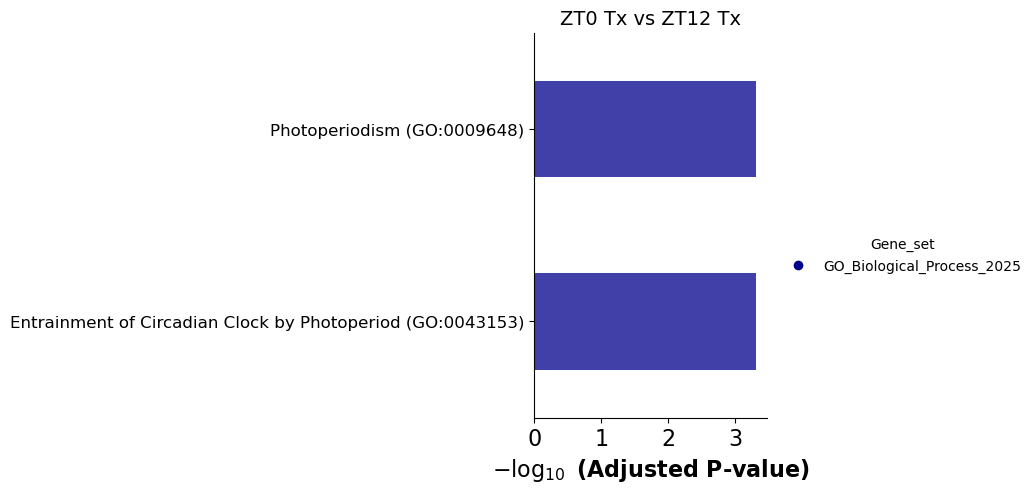

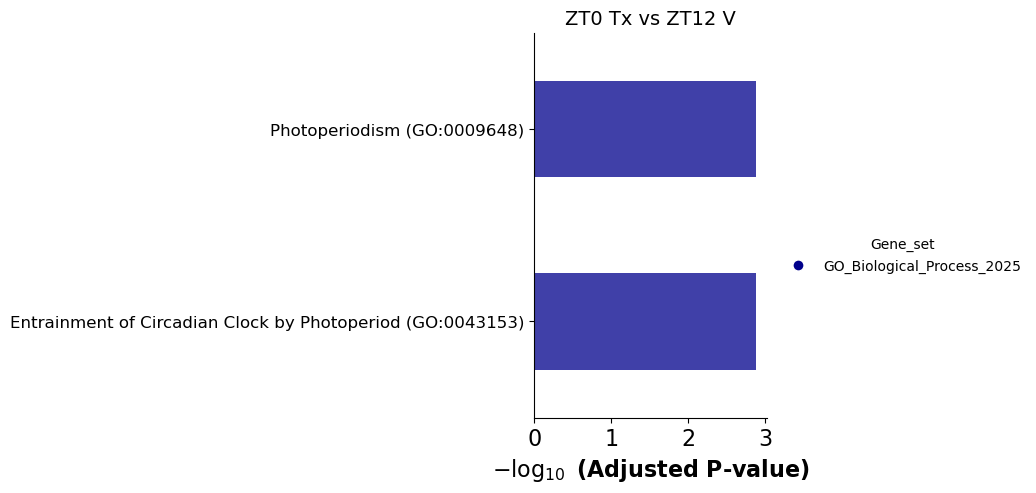

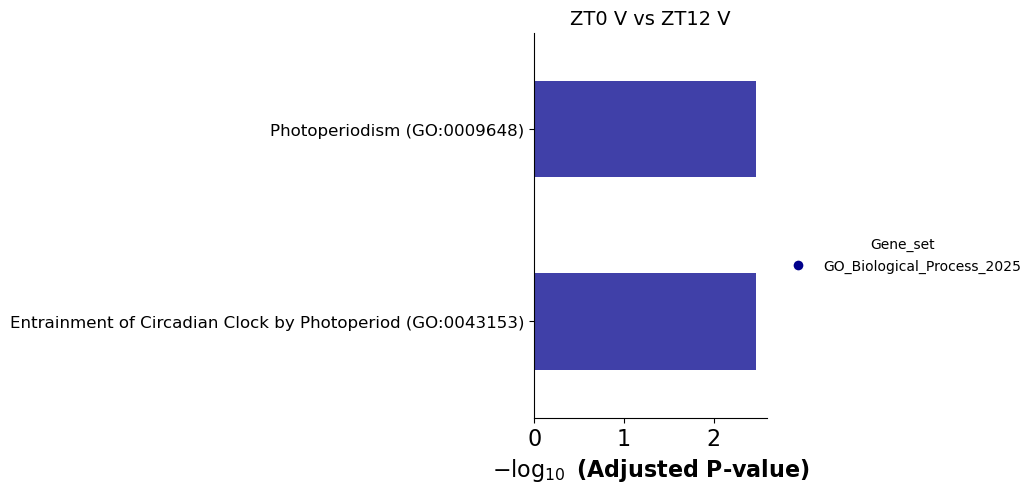

In [8]:
def enrichment_analysis(df, title):

    gene_list = list((df[df["regulation"] != "Unchange"]["external_gene_name"]).dropna())

    enr = gp.enrichr(gene_list=gene_list,
                    gene_sets=['GO_Biological_Process_2025'],
                    organism='Mouse', 
                    background=None,
                    outdir=None, # don't write to disk
                    )
    enr.results = enr.results[enr.results["Adjusted P-value"] < 0.1] 
    print("{title}\n", enr.results.head(), "\n\n")
    ax = barplot(enr.results,
                #column="Adjusted P-value",
                group='Gene_set', # set group, so you could do a multi-sample/library comparsion
                size=10,
                #top_term=5, # show top 5 significant terms
                figsize=(3,5),
                #color=['darkred', 'darkblue'] # set colors for group
                color = {'GO_Biological_Process_2025':'darkblue'}
                )
    ax.set_title(title, fontsize=14)
    plt.yticks(fontsize=12)

    return enr

Tx_0_12_enr = enrichment_analysis(Tx_0_12, "ZT0 Tx vs ZT12 Tx")
Tx0_V12_enr = enrichment_analysis(Tx0_V12, "ZT0 Tx vs ZT12 V")
V_0_12_enr = enrichment_analysis(V_0_12, "ZT0 V vs ZT12 V")